# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Nguyễn Trọng Tú"  # TODO: Họ và tên
STUDENT_ID = "2551862"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Trọng Tú (2551862)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\MLIoT_LAB\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
row_max = np.max(logits, axis=1, keepdims=True)

# shifted_logits = ...
shifted_logits = logits - row_max

# exp_logits = ...
exp_logits = np.exp(shifted_logits)

# class_probabilities = ...
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis=1)

# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis=1)

print("shifted logits:", shifted_logits)
print("class probabilities:", class_probabilities)
print("predicted classes:", predicted_classes)
print("confidence scores: ", confidence_scores)

shifted logits: [[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]
class probabilities: [[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]
predicted classes: [0 1 2 0]
confidence scores:  [0.65900114 0.66524096 0.97555875 0.33333333]


In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = np.mean(X_train, axis=0)

# train_feature_std = ...
train_feature_std = np.std(X_train, axis=0)

# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean) / train_feature_std

# X_val_scaled = ...
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

print("Train feature mean:", train_feature_mean)
print("Train feature std:", train_feature_std)
print("X train scaled:", X_train_scaled)
print("X val scaled:", X_val_scaled)

Train feature mean: [172.5         69.16666667   1.65        28.16666667]
Train feature std: [ 7.47774476 13.04372987  0.79109629  7.64671316]
X train scaled: [[-0.3343254  -0.31943828 -0.56883088 -0.80644671]
 [ 1.0029762   0.83053953  0.94805147  0.89363014]
 [-1.671627   -1.4694161  -1.07445834 -1.19877214]
 [ 0.3343254   0.06388766 -0.18961029 -0.02179586]
 [-0.60178572 -0.70276422 -0.82164461 -0.54489643]
 [ 1.27043652  1.59719141  1.70649265  1.67828099]]
X val scaled: [[-0.06686508 -0.08944272 -0.31601716 -0.28334614]
 [ 2.34027779  1.98051735  2.21212011  2.20138156]]


In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
# correct_mask = ...
correct_mask = (predicted_classes == true_labels)

# high_confidence_mask = ...
high_confidence_mask = (confidence_scores >= confidence_threshold)

# review_mask = ...
review_mask = (~correct_mask) | (~high_confidence_mask)

# review_indices = ...
review_indices = np.where(review_mask)[0]

print("Correct mask:", correct_mask)
print("High confidence:", high_confidence_mask)
print("Review (cần kiểm tra lại):", review_mask)
print("Chỉ số mảng review", review_indices)

Correct mask: [ True False  True False]
High confidence: [False False  True False]
Review (cần kiểm tra lại): [ True  True False  True]
Chỉ số mảng review [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4

# normalized_batch = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

# augmented_batch = ...
augmented_batch = normalized_batch[:, :, ::-1, :].copy()

# augmented_batch[0, 0, 0, 0] = ...
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Trong bộ dữ liệu Automobile, các giá trị bị thiếu (missing values) được ký hiệu bằng dấu chấm hỏi (?).
3. symboling là một biến phân loại, đại diện cho chỉ số đánh giá rủi ro bảo hiểm của xe ô tô:
- Giá trị dương (+1, +2, +3): Xe được đánh giá là rủi ro cao. Số càng lớn thì hãng bảo hiểm đánh giá xe đó càng nguy hiểm.
- Giá trị bằng 0: Mức rủi ro trung bình.
- Giá trị âm (-1, -2, -3): Xe được đánh giá là an toàn. Số càng âm thì xe càng an toàn.


## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [26]:
# TODO D1
import pandas as pd
DATA_PATH = r'D:\MLIoT_LAB\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv'

# raw_df = ...
raw_df = pd.read_csv(DATA_PATH)

# raw_shape = ...
raw_shape = raw_df.shape

# raw_missing_marker_count = ...
raw_missing_marker_count = (raw_df == '?').sum().sum()

print("Shape:", raw_shape)
print("Tổng số dấu '?':", raw_missing_marker_count)

Shape: (205, 26)
Tổng số dấu '?': 59


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [27]:
# TODO D2
import numpy as np

# df_clean = ...
df_clean = raw_df.replace('?', np.nan)

# for column in NUMERIC_COLUMNS:
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
#     ...
# missing_by_column = ...
missing_by_column = df_clean.isna().sum()

print(missing_by_column[missing_by_column > 0]) 

normalized_losses    41
num_doors             2
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

1. Vì mỗi cột dạng số numeric trong bộ dữ liệu Automobile mang một ý nghĩa vật lý và đơn vị đo khác nhau. Nếu ta dùng chung một giá trị để điền vào tất cả các chỗ trống, ta sẽ làm mất đi đặc trưng thống kê của từng cột. Điều này tạo ra nhiễu lớn và làm sai lệch mối tương quan vật lý của dữ liệu.

2. Đối với cột price, ta nên lựa chọn Drop (xóa bỏ các dòng bị thiếu) vì:
- Đây là biến mục tiêu (Target Variable), price là giá trị mà ta muốn dự đoán hoặc muốn tìm hiểu xem các đặc trưng khác ảnh hưởng đến nó như thế nào.
- Tránh đưa ra định kiến: Nếu ta cố tình fill giá trị price bị thiếu bằng giá trị nào đó, tức là đang tự bịa ra một mức giá cho chiếc xe đó.
- Trong bộ dữ liệu: cột price chỉ thiếu 4/200 dòng nên việc drop không ảnh hưởng quá nhiều.

3. Cột normalized_losses trong bộ dữ liệu bị thiếu rất nhiều. Điều này gây ra 2 ảnh hưởng lớn khó xử lí là:
- Không thể Drop: Nếu ta chọn cách drop tất cả các dòng bị thiếu normalized_losses, ta sẽ mất đi một lượng dữ liệu khá lớn của toàn bộ tập dữ liệu. Số lượng xe còn lại có thể không đủ lớn để mô hình hoạt động hiệu quả.

- Nếu ta lựa chọn Fill: đồ thị phân phối của cột này sẽ xuất hiện một đỉnh bất thường ở ngay giá trị ta vừa điền. Nó làm giảm phương sai và có thể đánh lừa các thuật toán Machine Learning sau này.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [28]:
# TODO D3
import numpy as np

# analysis_df = ...
analysis_df = df_clean[AUTO_FEATURES].dropna()

# X_auto = ...
X_auto = analysis_df.to_numpy(dtype=np.float64)

# auto_feature_mean = ...
# auto_feature_std = ...
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)

# X_auto_scaled = ...
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

print("Kích thước ma trận X_auto:", X_auto.shape)
print("Mean X_auto_scaled:", np.mean(X_auto_scaled, axis=0).round(2))
print("Std X_auto_scaled:", np.std(X_auto_scaled, axis=0).round(2))

Kích thước ma trận X_auto: (199, 6)
Mean X_auto_scaled: [ 0.  0.  0. -0.  0. -0.]
Std X_auto_scaled: [1. 1. 1. 1. 1. 1.]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [29]:
# TODO D4
# price_index = ...
price_index = AUTO_FEATURES.index('price')

# price_z = ...
price_z = X_auto_scaled[:, price_index]

# price_outlier_mask = ...
price_outlier_mask = np.abs(price_z) > 2

# price_outliers = ...
price_outliers = analysis_df[price_outlier_mask]

display(price_outliers)

,curb_weight,engine_size,horsepower,city_mpg,highway_mpg,price
15,3230,209,182.0,16,22,30760.0
16,3380,209,182.0,16,22,41315.0
17,3505,209,182.0,15,20,36880.0
47,4066,258,176.0,15,19,32250.0
48,4066,258,176.0,15,19,35550.0
49,3950,326,262.0,13,17,36000.0
70,3770,183,123.0,22,25,31600.0
71,3740,234,155.0,16,18,34184.0
72,3685,234,155.0,16,18,35056.0
73,3900,308,184.0,14,16,40960.0


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [30]:
# TODO D5

# engine_price_corr = ...
engine_arr = analysis_df['engine_size'].to_numpy(dtype=np.float64)
price_arr = analysis_df['price'].to_numpy(dtype=np.float64)
engine_price_corr = np.corrcoef(engine_arr, price_arr)[0, 1]

# price_by_body_style = ...
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

print(f"Hệ số tương quan giữa kích thước động cơ và giá xe: {engine_price_corr:.4f}")
print("\nGiá trung bình theo loại thân xe:")
print(price_by_body_style)

Hệ số tương quan giữa kích thước động cơ và giá xe: 0.8739

Giá trung bình theo loại thân xe:
body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

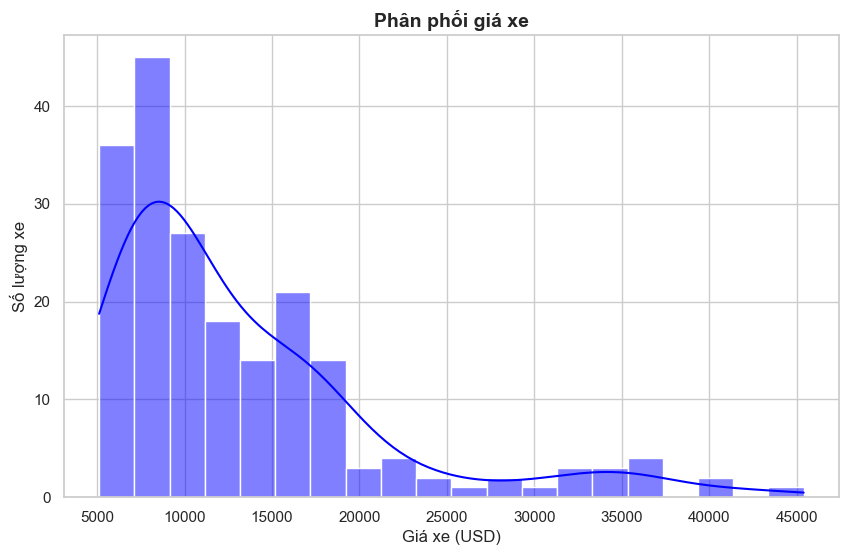

In [31]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='price', kde=True, bins=20, color='blue')

plt.title('Phân phối giá xe', fontsize=14, fontweight='bold')
plt.xlabel('Giá xe (USD)', fontsize=12)
plt.ylabel('Số lượng xe', fontsize=12)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Phân phối giá xe bị lệch phải. Phần lớn các mẫu xe trong bộ dữ liệu tập trung ở phân khúc phổ thông có giá từ 5,000 đến 15,000 USD. Chỉ có một số lượng rất ít các mẫu xe thuộc phân khúc hạng sang (vượt mốc 30,000 USD).

## M2.2 Dataset có cân bằng theo body style không?

C:\Users\Admin\AppData\Local\Temp\ipykernel_19080\3354055643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='body_style', palette='viridis', order=df_clean['body_style'].value_counts().index)


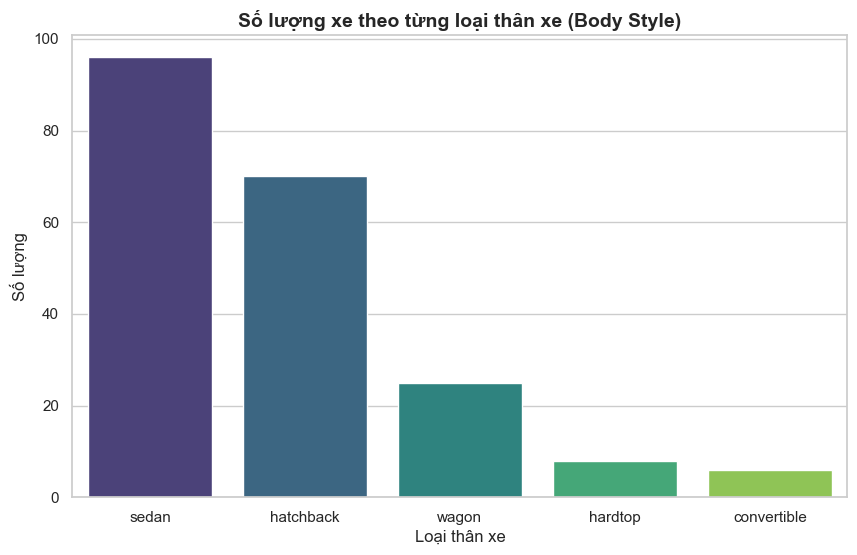

In [32]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='body_style', palette='viridis', order=df_clean['body_style'].value_counts().index)

plt.title('Số lượng xe theo từng loại thân xe (Body Style)', fontsize=14, fontweight='bold')
plt.xlabel('Loại thân xe', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Dataset khá mất cân bằng. Dòng xe sedan và hatchback áp đảo toàn bộ thị phần trong dữ liệu, trong khi các dòng xe đặc thù như convertible hay hardtop chiếm số lượng cực kỳ ít. Điều này phản ánh đúng cơ cấu thị trường ô tô thực tế.

## M2.3 Price khác nhau theo body style ra sao?

C:\Users\Admin\AppData\Local\Temp\ipykernel_19080\2700989273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')


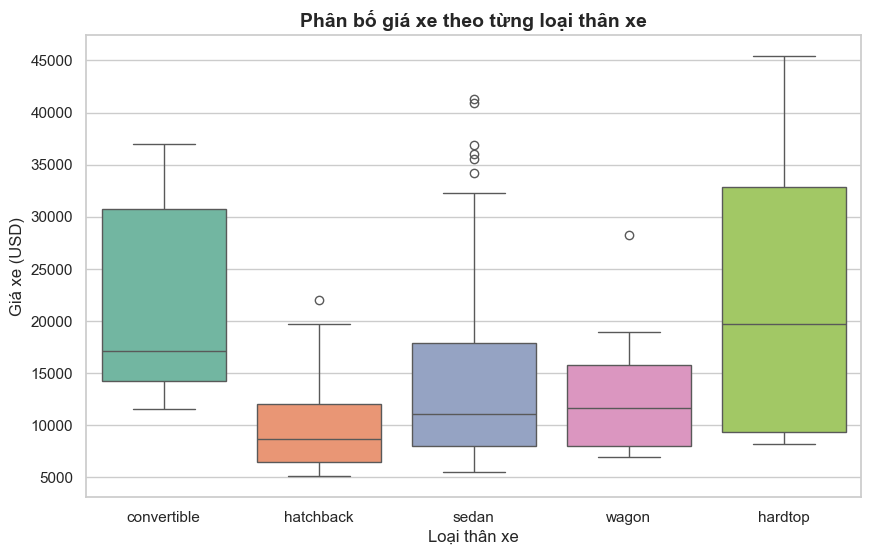

In [33]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')

plt.title('Phân bố giá xe theo từng loại thân xe', fontsize=14, fontweight='bold')
plt.xlabel('Loại thân xe', fontsize=12)
plt.ylabel('Giá xe (USD)', fontsize=12)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Xe hardtop và convertible có mức giá trung vị cao nhất và dải giá dao động rất rộng. Ngược lại, hatchback được định vị rõ ràng là dòng xe giá rẻ với mức giá thấp nhất và ít có sự biến động. Dòng sedan có nhiều xe ngoại lai (outliers) vọt lên mức giá cao.

## M2.4 Engine size liên quan thế nào tới price?

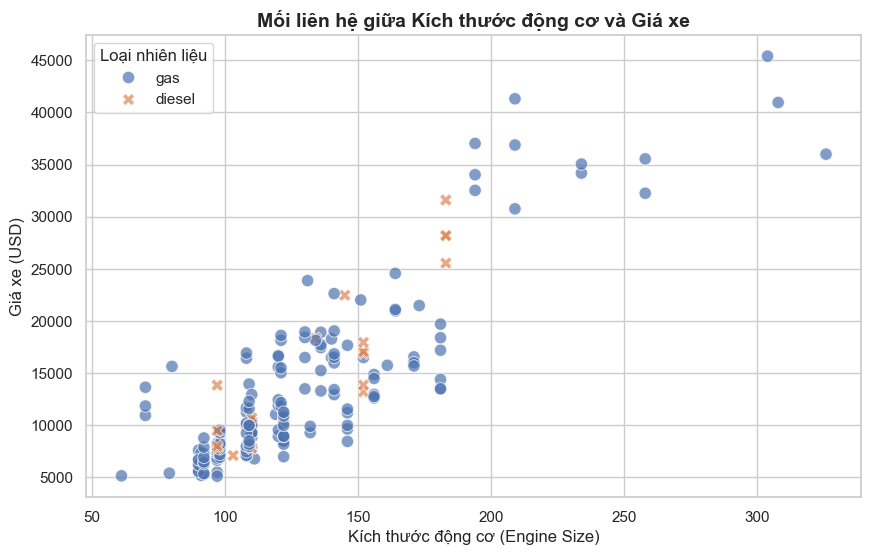

In [34]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', style='fuel_type', s=80, alpha=0.7)

plt.title('Mối liên hệ giữa Kích thước động cơ và Giá xe', fontsize=14, fontweight='bold')
plt.xlabel('Kích thước động cơ (Engine Size)', fontsize=12)
plt.ylabel('Giá xe (USD)', fontsize=12)
plt.legend(title='Loại nhiên liệu')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Có một mối tương quan tuyến tính dương mạnh: Động cơ càng lớn thì xe càng đắt. Bên cạnh đó, xe chạy xăng (gas) bao phủ toàn bộ mọi phân khúc giá, trong khi xe chạy diesel đa phần chỉ tập trung ở vùng động cơ trung bình và mức giá dao động từ 10,000 đến 30,000 USD.

## M2.5 Các feature numeric tương quan ra sao?

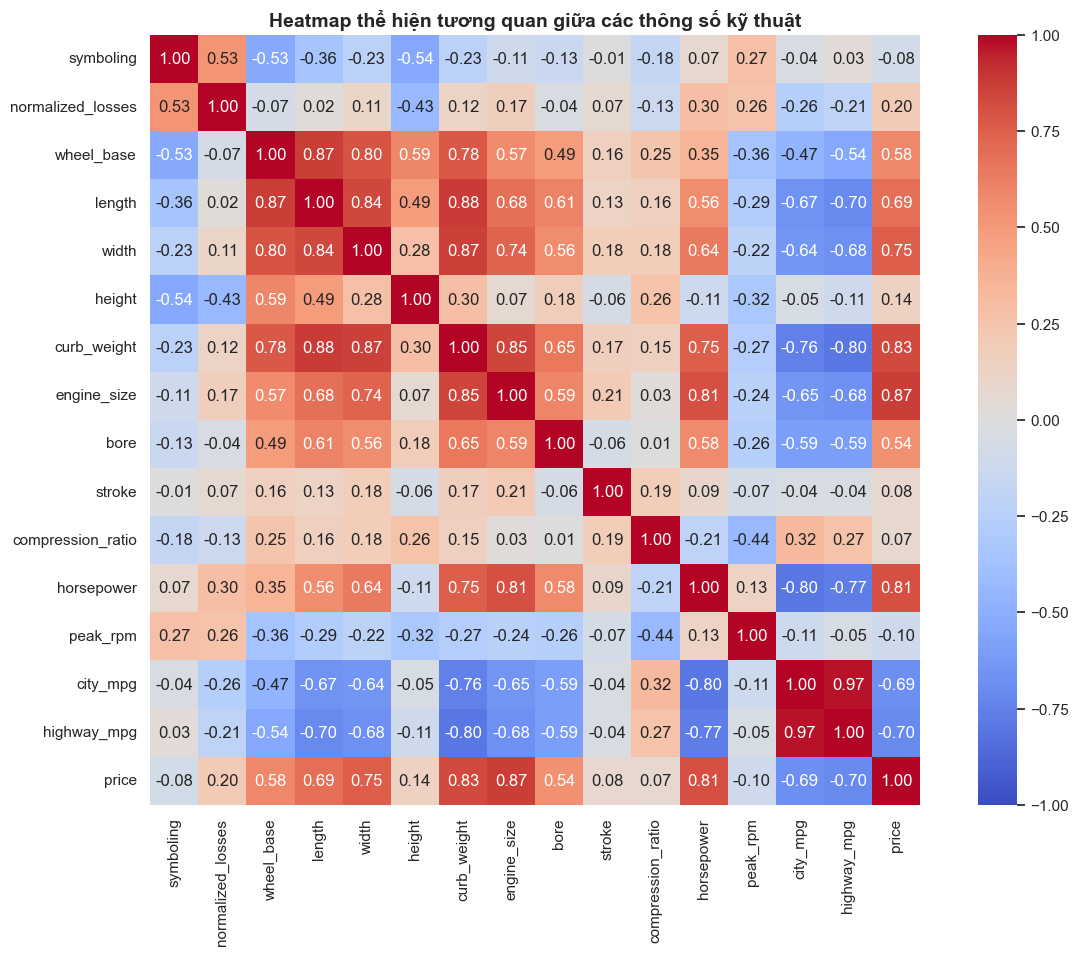

In [37]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(15, 10))

numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Heatmap thể hiện tương quan giữa các thông số kỹ thuật', fontsize=14, fontweight='bold')
plt.show()

- price có tương quan dương cực kỳ mạnh với engine_size, curb_weight (trọng lượng) và horsepower (mã lực).
- price và engine_size lại có tương quan âm mạnh với city_mpg và highway_mpg. Điều này khẳng định rằng: xe càng to, máy càng khỏe thì chạy càng tốn xăng.

**Nhận xét:** <!-- 1--2 câu -->

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

Câu hỏi đặt ra: Khả năng tiết kiệm nhiên liệu trên cao tốc (highway_mpg) thay đổi như thế nào giữa các hệ dẫn động (drive_wheels)?


C:\Users\Admin\AppData\Local\Temp\ipykernel_19080\2268790165.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='drive_wheels', y='highway_mpg', palette='pastel')


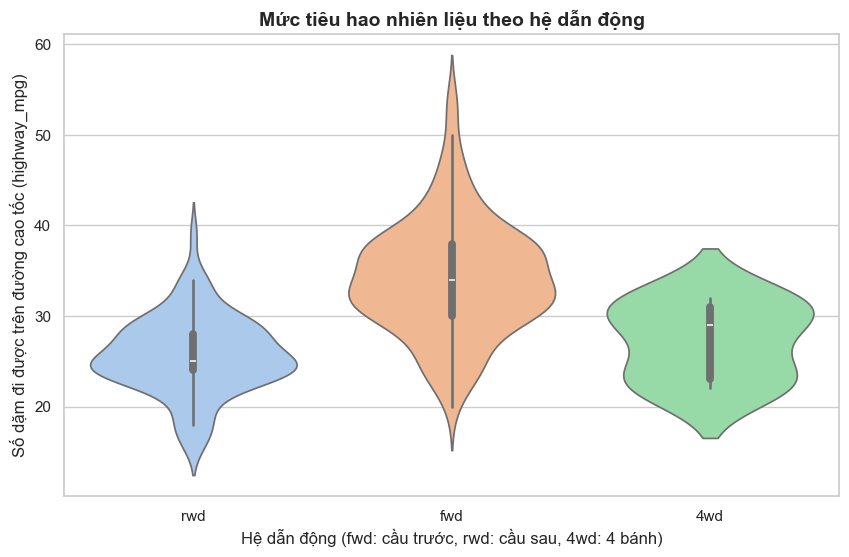

In [38]:
# TODO M2.6: biểu đồ tự chọn
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_clean, x='drive_wheels', y='highway_mpg', palette='pastel')

plt.title('Mức tiêu hao nhiên liệu theo hệ dẫn động', fontsize=14, fontweight='bold')
plt.xlabel('Hệ dẫn động (fwd: cầu trước, rwd: cầu sau, 4wd: 4 bánh)', fontsize=12)
plt.ylabel('Số dặm đi được trên đường cao tốc (highway_mpg)', fontsize=12)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Xe dẫn động cầu trước (fwd) mang lại khả năng tiết kiệm nhiên liệu vượt trội nhất (chạy được nhiều dặm nhất). Xe dẫn động 4 bánh (4wd) và cầu sau (rwd) tiêu hao nhiên liệu nhiều hơn hẳn do kết cấu cơ khí phức tạp, xe nặng hơn và có sự thất thoát lực truyền động lớn.

Lựa chọn Violin Plot (biểu đồ vĩ cầm) cho cặp biến drive_wheels (loại hệ dẫn động - biến phân loại) và highway_mpg (mức tiêu hao nhiên liệu cao tốc - biến số liên tục) dùng để khai thác tối đa thông tin từ dữ liệu.

Violin Plot thực chất là sự kết hợp giữa Boxplot (Biểu đồ hộp) và KDE (Biểu đồ mật độ phân phối). Với Violin Plot, phần thân biểu đồ phình to ở đâu, nghĩa là có rất nhiều xe tập trung ở mức MPG đó. Nếu nó thắt lại, nghĩa là có rất ít xe. Điều này giúp ta thấy rõ dòng xe cầu trước (fwd) có thực sự chụm lại ở một mức tiết kiệm nhiên liệu lý tưởng hay không, hay phân tán rải rác.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

1. 3-5 phát hiện chính:
- Động cơ quyết định giá trị: Kích thước động cơ (engine_size) là yếu tố dự báo giá xe (price) tốt nhất, thể hiện qua hệ số tương quan dương rất cao trên Heatmap và xu hướng rõ ràng ở biểu đồ scatter plot.
- Định vị phân khúc qua hình dáng: Khách hàng muốn mua xe giá rẻ sẽ hướng tới hatchback, trong khi các xe hạng sang, giá cao thường mang kiểu dáng hardtop hoặc convertible (thể hiện ở Boxplot M2.3).
- Sự đánh đổi về nhiên liệu: Xe có trọng lượng nặng (curb_weight) và mã lực cao (horsepower) sẽ phải đánh đổi bằng mức tiêu thụ nhiên liệu rất kém (city_mpg, highway_mpg giảm mạnh) và tương quan âm rõ rệt.

2. 2 hạn chế của Dataset:
- Mất cân bằng: Các biến phân loại như body_style hay fuel_type bị mất cân bằng (quá nhiều sedan/gas, quá ít convertible/diesel), có thể làm mô hình AI dự đoán kém cho các nhóm thiểu số này.
- Kích thước mẫu nhỏ và khuyết dữ liệu: Dữ liệu chỉ có khoảng hơn 200 dòng, trong đó một số cột quan trọng như normalized_losses lại bị thiếu khá nhiều dữ liệu, gây khó khăn cho việc nội suy.

3. Một ví dụ về correlation không đồng nghĩa causation:
- Ví dụ: Tương quan giữa price (giá xe) và highway_mpg (số dặm đi được) là số âm (tương quan nghịch).
- Điều này không có nghĩa là: cứ cố làm cho xe hao xăng đi thì nhà sản xuất sẽ bán được giá cao hơn. Bản chất của sự tương quan nghịch này bị chi phối bởi một biến khác: Kích thước khối động cơ/trọng lượng xe. Xe đắt tiền thì thường được trang bị động cơ to, nội thất nặng, dẫn đến giá cao và hao xăng.

4. Câu hỏi phân tích thêm: Yếu tố thương hiệu (make) đóng giá trị bao nhiêu tiền vào giá bán cuối cùng của một chiếc xe?

Chúng ta đã biết động cơ to thì giá đắt. Nhưng phân tích tiếp theo nên làm rõ: Liệu một chiếc BMW và một chiếc Toyota nếu có cùng kích thước động cơ, cùng mã lực thì mức giá chênh lệch nhau bao nhiêu chỉ vì khác biệt về logo/thương hiệu?